<a href="https://colab.research.google.com/github/sakeththelu/NLP/blob/main/nlp_ass_11_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

# Download necessary resources
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Load Dataset (Example structure)
# data =["/content/movie_reviews.csv.zip"]
# df = pd.DataFrame(data)
df = pd.read_csv('/content/movie_reviews.csv.zip')

def clean_review(text):
    # a. Remove HTML tags (like <br>)
    text = re.sub(r'<.*?>', '', text)
    # b. Remove punctuation and numbers, keep only letters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # c. Convert to lowercase
    text = text.lower()
    # d. Remove stopwords
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

# 2. Apply Cleaning
df['processed_review'] = df['review'].apply(clean_review)

# 3. Display Sample Processed Text
print("--- Comparison ---")
print(f"Original:  {df['review'][0]}")
print(f"Processed: {df['processed_review'][0]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- Comparison ---
Original:  One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer
# ngram_range=(1,2) allows the model to see single words AND two-word pairs like "not good"
tfidf = TfidfVectorizer(ngram_range=(1,1))

# Fit and transform the processed reviews
tfidf_matrix = tfidf.fit_transform(df['processed_review'])

# 2. Display Vocabulary Size
vocab = tfidf.get_feature_names_out()
print(f"Total Unique Words (Vocabulary Size): {len(vocab)}")
print(f"Sample words from vocabulary: {vocab[:10]}")

Total Unique Words (Vocabulary Size): 214460
Sample words from vocabulary: ['aa' 'aaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' 'aaaaaaaargh' 'aaaaaaah'
 'aaaaaaahhhhhhggg' 'aaaaagh' 'aaaaah' 'aaaaargh'
 'aaaaarrrrrrgggggghhhhhh']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, df['sentiment'], test_size=0.2, random_state=42
)

# 2. Train Logistic Regression with tuned max_iter
# max_iter is the number of attempts the solver takes to converge on the best weights.
# For large text datasets, 100 (default) might be too low; 1000 is safer.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


Overall Accuracy: 0.90

Detailed Report:
              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4961
    Positive       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



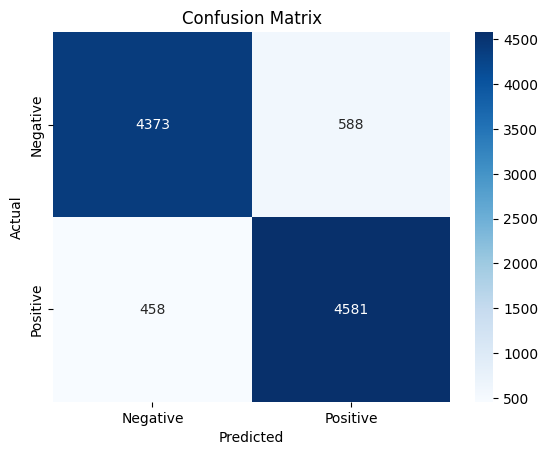

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Predictions
y_pred = model.predict(X_test)

# 2. Print Metrics
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# 3. Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Training Accuracy: 93.52%
Training Recall:   94.25%


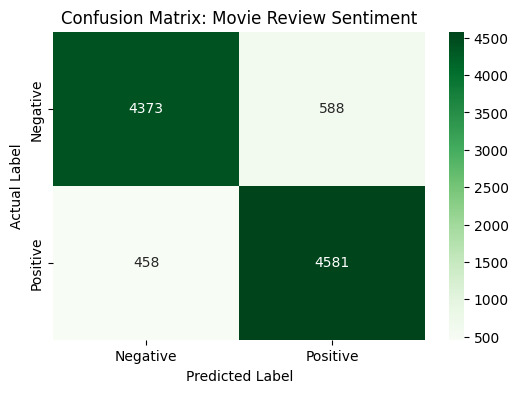

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions for both sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 2. Calculate Training Metrics
train_acc = accuracy_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred, pos_label='positive')

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Training Recall:   {train_rec:.2%}")

# 3. Create the Confusion Matrix for the Test Set
cm = confusion_matrix(y_test, y_test_pred)

# 4. Visualize with a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix: Movie Review Sentiment')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()